In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

VIDEO_PATH = "../data/raw/Registro A_2.MOV"

Abrimos el vídeo

In [3]:
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError(f"No se pudo abrir el video: {VIDEO_PATH}")

print("Video abierto correctamente.")

Video abierto correctamente.


Sacamos los fps, la cantidad de frames, ancho y alto, duración. 

In [4]:
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = n_frames / fps

print(f"Resolución: {width} × {height} píxeles")
print(f"FPS: {fps:.2f}")
print(f"Cantidad de frames: {n_frames}")
print(f"Duración: {duration:.2f} segundos")

Resolución: 1920 × 1080 píxeles
FPS: 29.98
Cantidad de frames: 956
Duración: 31.89 segundos


Tomamos el frame representativo desde la mitad del video. 

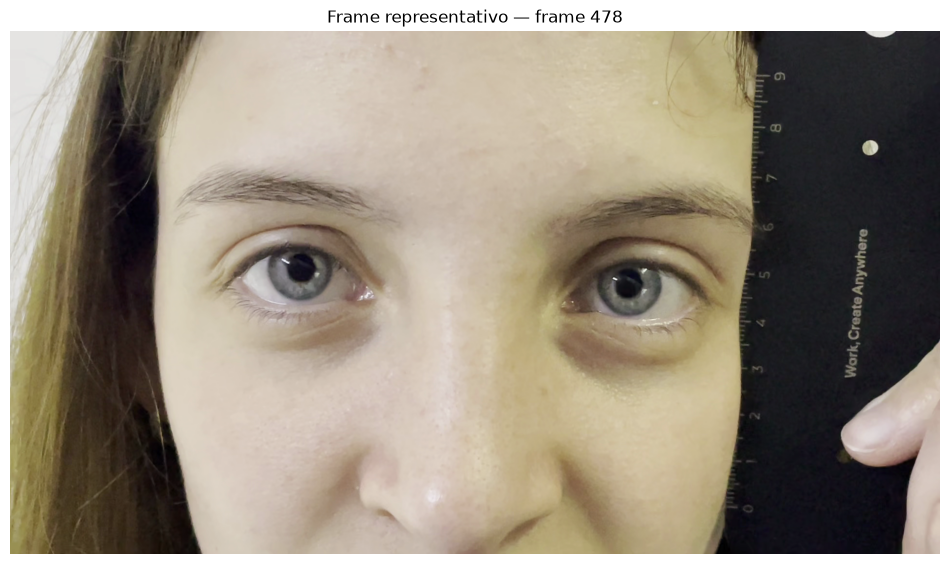

In [5]:
frame_index = n_frames // 2

cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
ret, frame_bgr = cap.read()

if not ret:
    raise RuntimeError("No se pudo leer el frame seleccionado.")

# OpenCV utiliza BGR; Matplotlib utiliza RGB
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(frame_rgb)
plt.title(f"Frame representativo — frame {frame_index}")
plt.axis("off")
plt.show()

Ahora elegimos el ROI

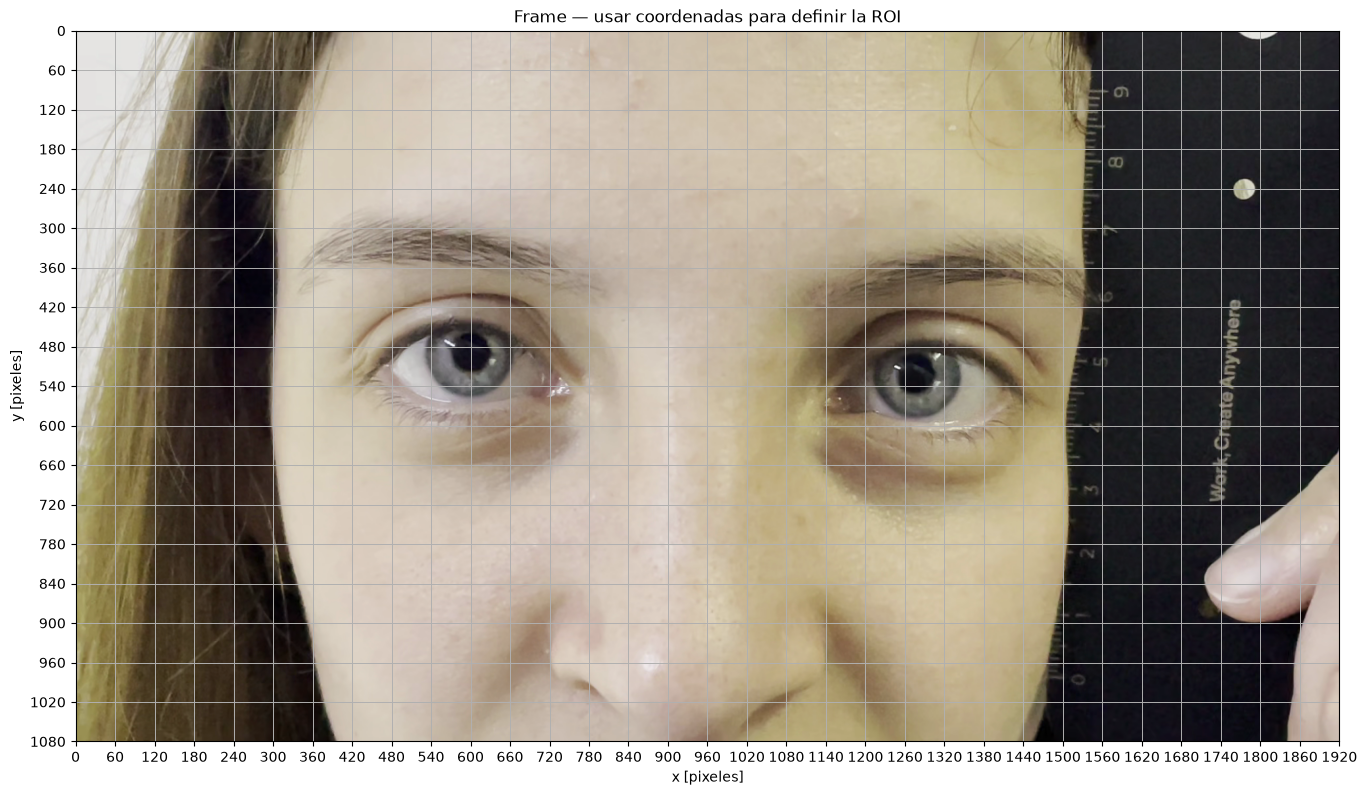

In [24]:
plt.figure(figsize=(14, 8))
plt.imshow(frame_rgb)
# Grilla cada 50 píxeles
plt.xticks(np.arange(0, width + 1, 60))
plt.yticks(np.arange(0, height + 1, 60))
plt.xlim(0, width)
plt.ylim(height, 0)
plt.grid(True, linewidth=0.7)
plt.xlabel("x [pixeles]")
plt.ylabel("y [pixeles]")
plt.title("Frame — usar coordenadas para definir la ROI")
plt.tight_layout()
plt.show()

 abajo izquierda x=1120 y=600
 abajo derecha x=1440 y=600
 arriba izquierda x=1120 y=480
 arriba derecha x=1440 y=480

In [29]:
x = 1120
y = 470
w = 1440-1120
h = 600-470

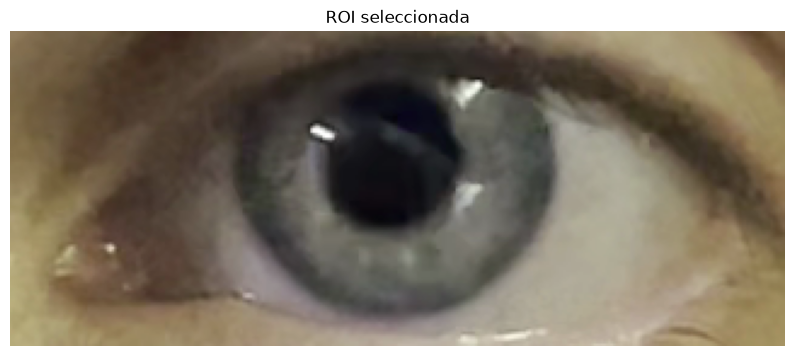

In [30]:
roi_rgb = frame_rgb[y:y+h, x:x+w]

plt.figure(figsize=(10, 6))
plt.imshow(roi_rgb)
plt.axis("off")
plt.title("ROI seleccionada")
plt.show()

In [32]:
roi_height, roi_width = roi_rgb.shape[:2]
# Profundidad de bits por canal
bits_por_canal = roi_rgb.dtype.itemsize * 8

print(f"Ancho de la ROI: {roi_width} píxeles")
print(f"Alto de la ROI: {roi_height} píxeles")
print(f"Canales: {roi_rgb.shape[2]}")
print(f"Profundidad: {bits_por_canal} bits por canal")

Ancho de la ROI: 320 píxeles
Alto de la ROI: 130 píxeles
Canales: 3
Profundidad: 8 bits por canal


Submuestro de la ROI al 50%, 25% y 5%

ROI original: (130, 320, 3)
ROI 50%: (65, 160, 3)
ROI 25%: (32, 80, 3)
ROI 5%: (6, 16, 3)


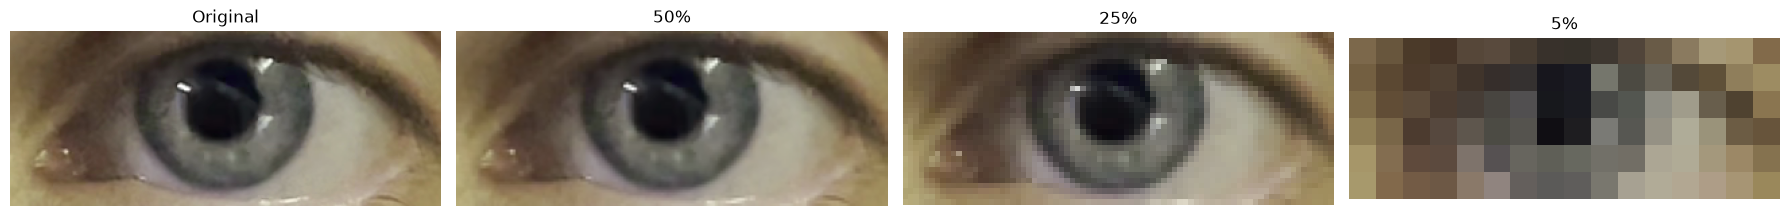

In [34]:
roi_50 = cv2.resize(roi_rgb, None, fx=0.50, fy=0.50, interpolation=cv2.INTER_AREA)
roi_25 = cv2.resize(roi_rgb, None, fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)
roi_05 = cv2.resize(roi_rgb, None, fx=0.05, fy=0.05, interpolation=cv2.INTER_AREA)

print("ROI original:", roi_rgb.shape)
print("ROI 50%:", roi_50.shape)
print("ROI 25%:", roi_25.shape)
print("ROI 5%:", roi_05.shape)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(roi_rgb)
axes[0].set_title("Original")

axes[1].imshow(roi_50)
axes[1].set_title("50%")

axes[2].imshow(roi_25)
axes[2].set_title("25%")

axes[3].imshow(roi_05)
axes[3].set_title("5%")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

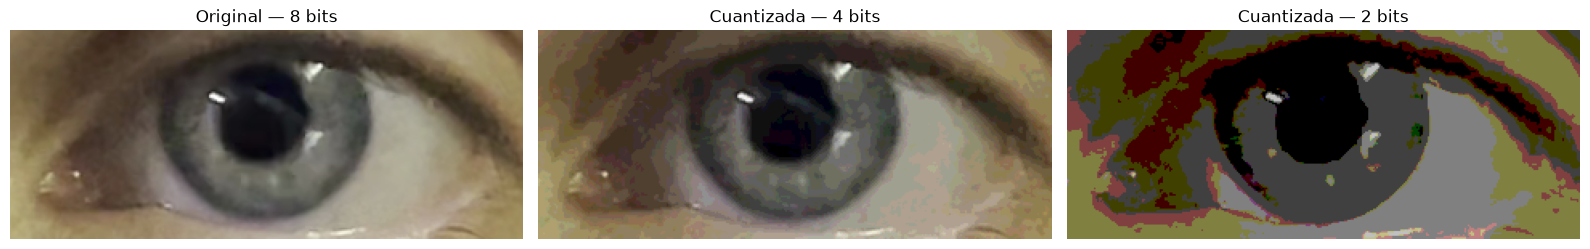

In [36]:
# Cuantización a 4 bits
roi_4bits = (roi_rgb // 16) * 16

# Cuantización a 2 bits
roi_2bits = (roi_rgb // 64) * 64

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(roi_rgb)
axes[0].set_title("Original — 8 bits")

axes[1].imshow(roi_4bits)
axes[1].set_title("Cuantizada — 4 bits")

axes[2].imshow(roi_2bits)
axes[2].set_title("Cuantizada — 2 bits")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

Espacios de color --> separar los canales y convertir de RGB a HSV

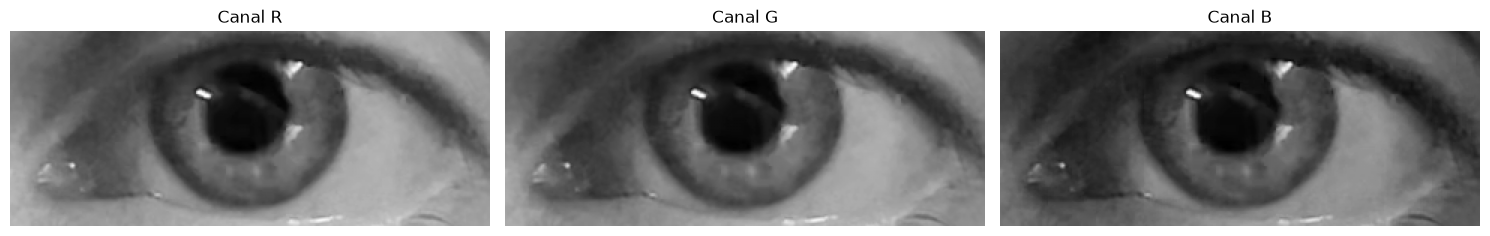

In [38]:
R = roi_rgb[:, :, 0]
G = roi_rgb[:, :, 1]
B = roi_rgb[:, :, 2]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(R, cmap="gray")
axes[0].set_title("Canal R")

axes[1].imshow(G, cmap="gray")
axes[1].set_title("Canal G")

axes[2].imshow(B, cmap="gray")
axes[2].set_title("Canal B")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

Convetimos la ROI a escala de grises

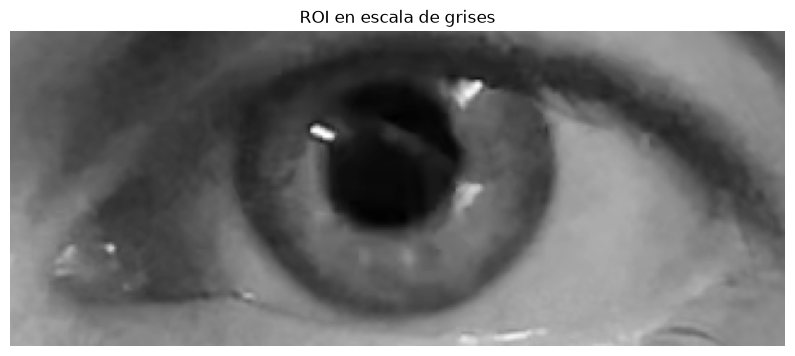

In [40]:
roi_gray = cv2.cvtColor(roi_rgb, cv2.COLOR_RGB2GRAY)
plt.figure(figsize=(10, 6))
plt.imshow(roi_gray, cmap="gray")
plt.axis("off")
plt.title("ROI en escala de grises")
plt.show()

Convertimos a HSV

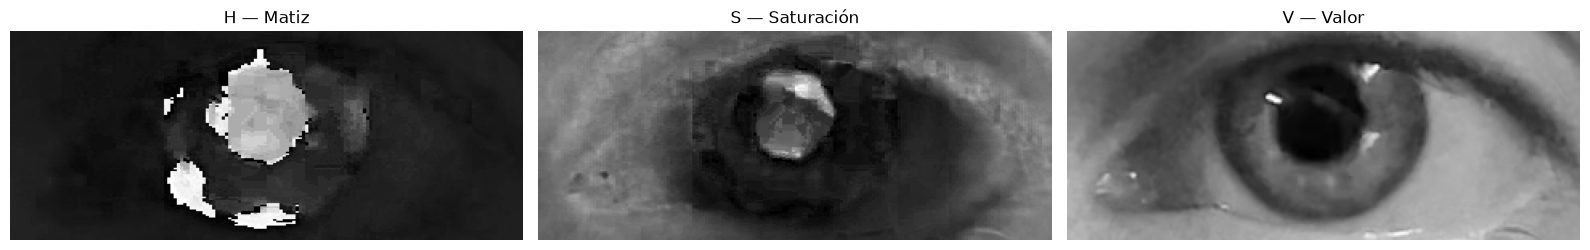

H: 0 → 178
S: 0 → 216
V: 11 → 255


In [42]:
roi_hsv = cv2.cvtColor(roi_rgb, cv2.COLOR_RGB2HSV)

H = roi_hsv[:, :, 0]
S = roi_hsv[:, :, 1]
V = roi_hsv[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(H, cmap="gray")
axes[0].set_title("H — Matiz")

axes[1].imshow(S, cmap="gray")
axes[1].set_title("S — Saturación")

axes[2].imshow(V, cmap="gray")
axes[2].set_title("V — Valor")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"H: {H.min()} → {H.max()}")
print(f"S: {S.min()} → {S.max()}")
print(f"V: {V.min()} → {V.max()}")

HISTOGRAMA

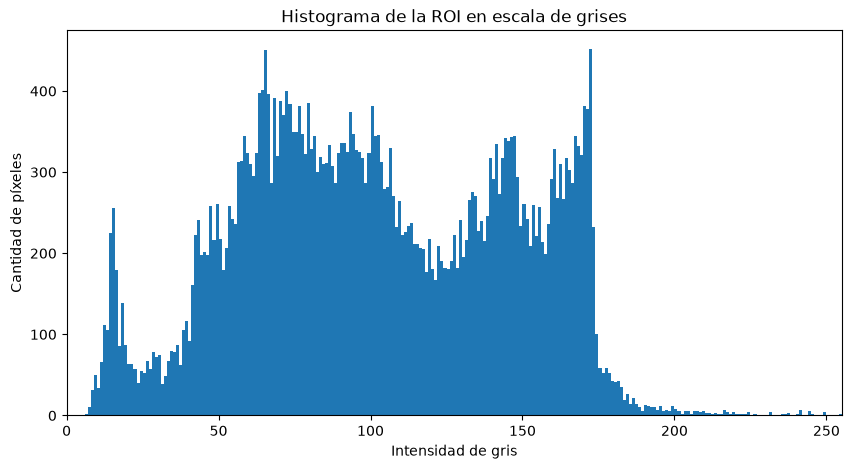

In [43]:
plt.figure(figsize=(10, 5))

plt.hist(roi_gray.ravel(), bins=256, range=(0, 256))

plt.title("Histograma de la ROI en escala de grises")
plt.xlabel("Intensidad de gris")
plt.ylabel("Cantidad de píxeles")
plt.xlim(0, 255)

plt.show()

Modificamos el brillo y el contraste

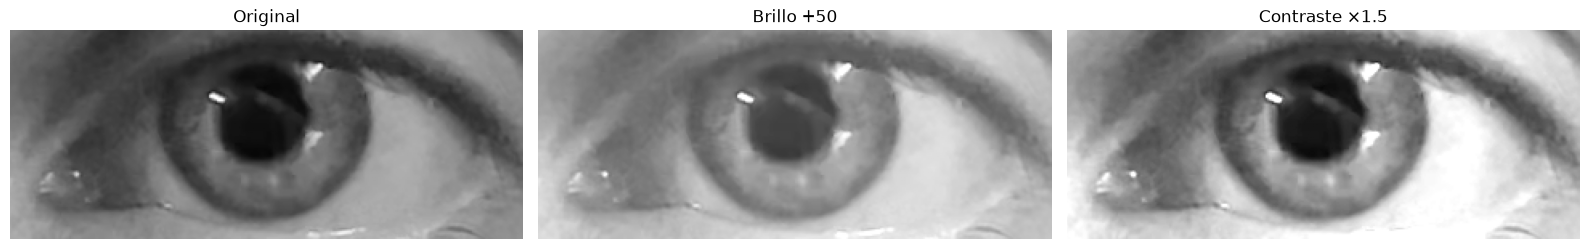

In [44]:
roi_brillo = np.clip(roi_gray.astype(np.int16) + 50, 0, 255).astype(np.uint8)
roi_contraste = np.clip(roi_gray.astype(np.float32) * 1.5, 0, 255).astype(np.uint8)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(roi_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")

axes[1].imshow(roi_brillo, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Brillo +50")

axes[2].imshow(roi_contraste, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Contraste ×1.5")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

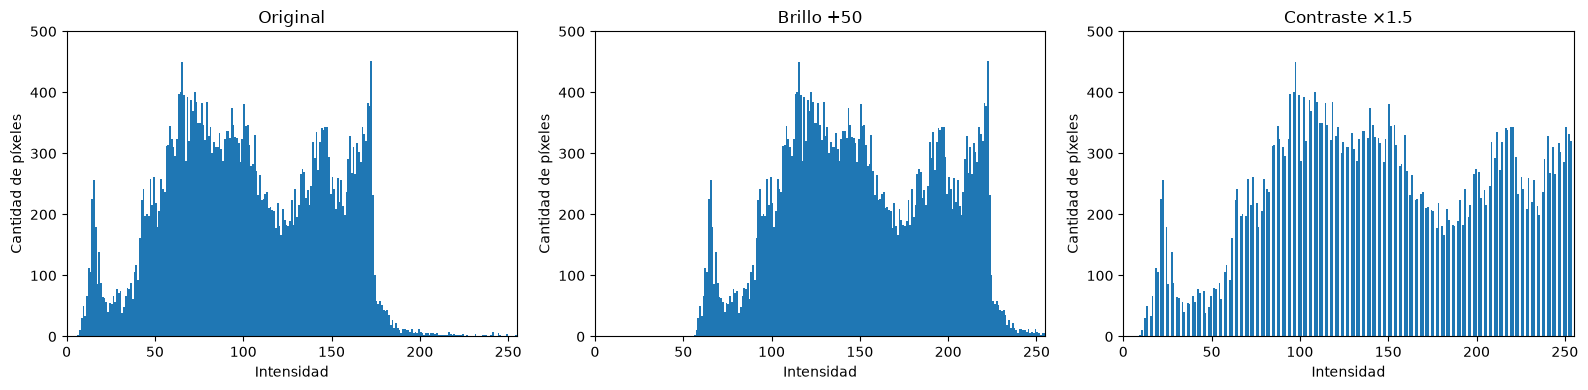

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(roi_gray.ravel(), bins=256, range=(0, 256))
axes[0].set_title("Original")

axes[1].hist(roi_brillo.ravel(), bins=256, range=(0, 256))
axes[1].set_title("Brillo +50")

axes[2].hist(roi_contraste.ravel(), bins=256, range=(0, 256))
axes[2].set_title("Contraste ×1.5")

for ax in axes:
    ax.set_xlim(0, 255)
    ax.set_ylim(0, 500)
    ax.set_xlabel("Intensidad")
    ax.set_ylabel("Cantidad de píxeles")

plt.tight_layout()
plt.show()

Al aumentarle el brillo sumandole una constante al histograma, se corre todo el espectro en conjunto. En cambio, cuando mejoramos el contraste de la imagen multiplicando por un factor de 1.5, se observa un efecto similar a una ecualización. Los extremos del espectro de nuestra imagen se corren a los extremos del histograma, usándose mejor el rango de 0 a 255. 

Escalado por rango de interés

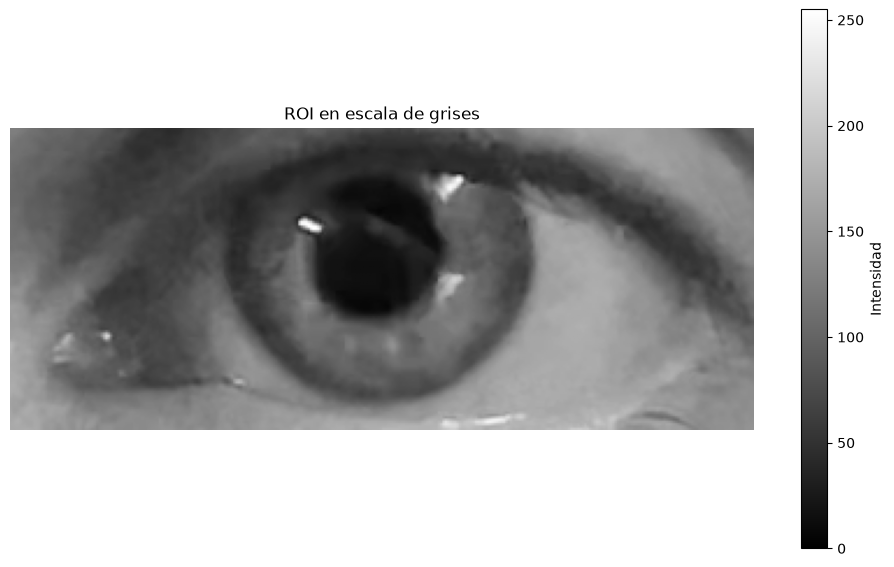

In [54]:
plt.figure(figsize=(12, 7))

plt.imshow(roi_gray, cmap="gray", vmin=0, vmax=255)
plt.colorbar(label="Intensidad")
plt.title("ROI en escala de grises")
plt.axis("off")

plt.show()

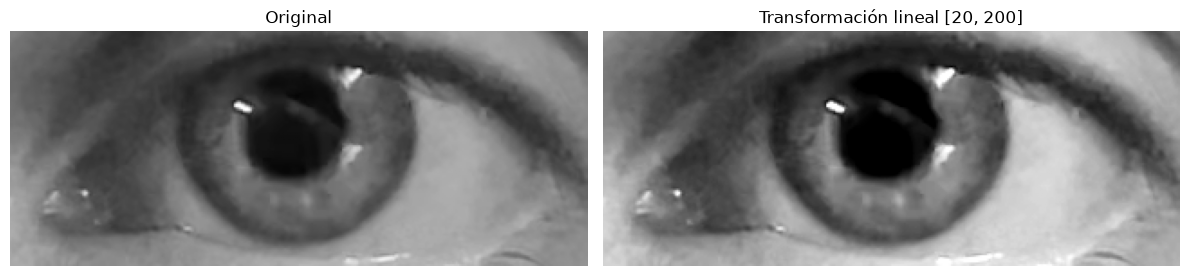

In [59]:
f1 = 20   
f2 = 200 

roi_lineal = (roi_gray.astype(np.float32) - f1) / (f2 - f1) * 255

roi_lineal = np.clip(roi_lineal, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(roi_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")

axes[1].imshow(roi_lineal, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Transformación lineal [{f1:.0f}, {f2:.0f}]")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

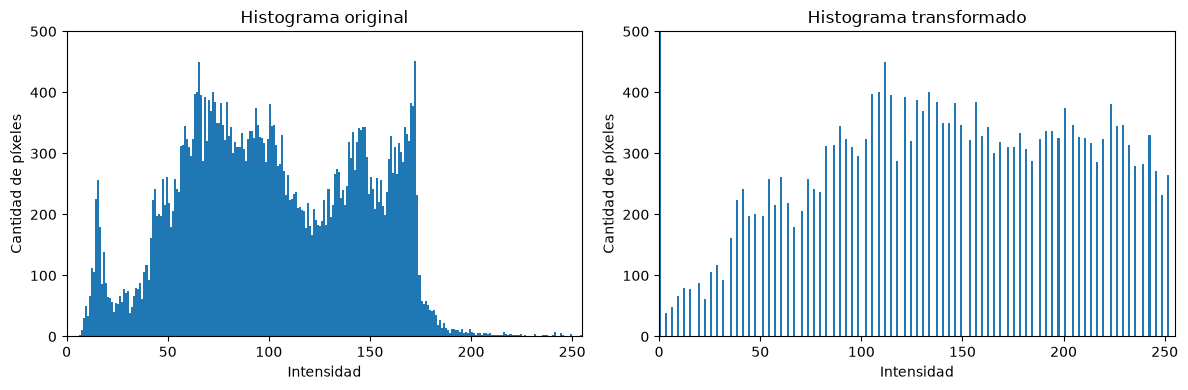

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(roi_gray.ravel(), bins=256, range=(0, 256))
axes[0].set_title("Histograma original")

axes[1].hist(roi_lineal.ravel(), bins=256, range=(0, 256))
axes[1].set_title("Histograma transformado")

for ax in axes:
    ax.set_xlim(0, 255)
    ax.set_ylim(0, 500)
    ax.set_xlabel("Intensidad")
    ax.set_ylabel("Cantidad de píxeles")

plt.tight_layout()
plt.show()

Ecualización del histograma

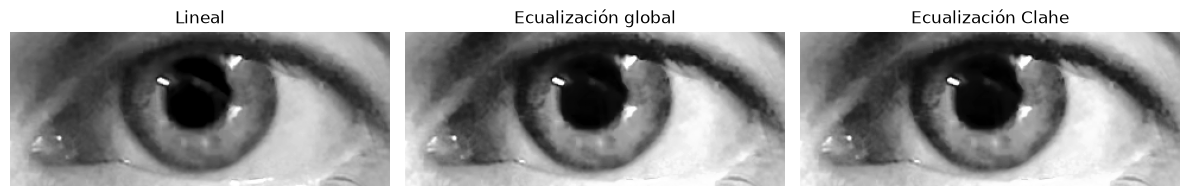

In [66]:
roi_equalizada = cv2.equalizeHist(roi_gray)
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

roi_clahe = clahe.apply(roi_gray)
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].imshow(roi_lineal, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Lineal")

axes[1].imshow(roi_equalizada, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Ecualización global")

axes[2].imshow(roi_equalizada, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Ecualización Clahe")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

La ecualización global y CLAHE se ven con menor nitidez con respecto a la transformación lineal. Además, hacen que la parte de las pestañas se vean igual de oscuras que la pupila haciendo que se vean más juntas y se distinga menos la separación. 
Se podría decir que se le agrega ruido gaussiano. 

La transformación lineal es la que nos permite distinguir mejor entre la pupila y el iris. CLAHE es la que da peores resultados.

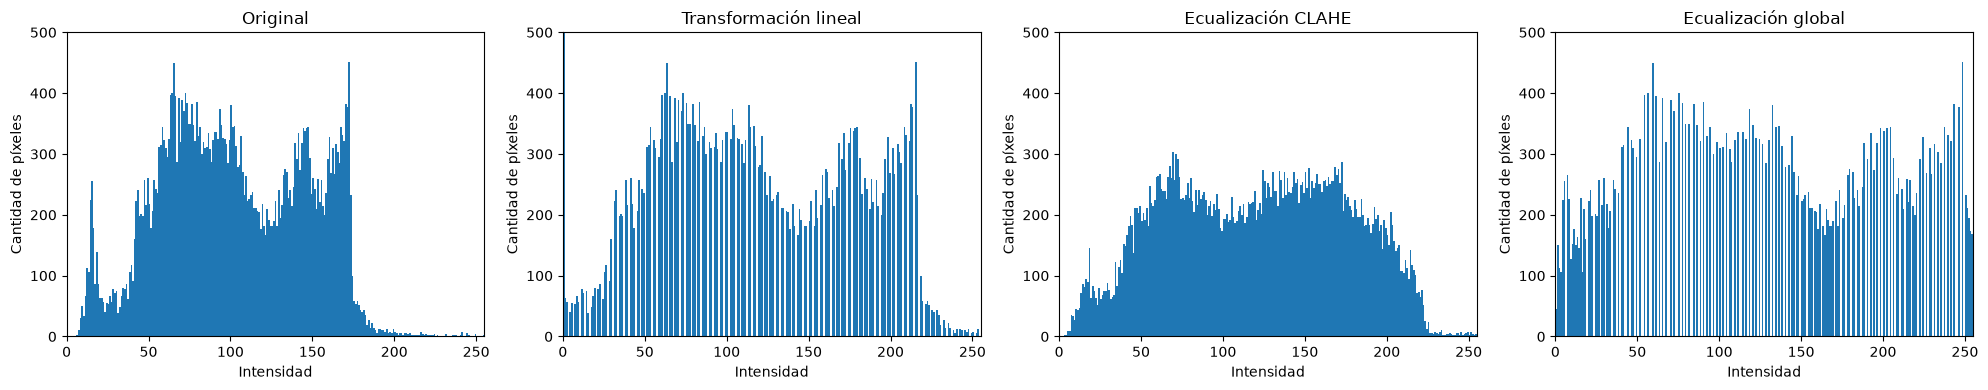

In [70]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].hist(roi_gray.ravel(), bins=256, range=(0, 256))
axes[0].set_title("Original")

axes[1].hist(roi_lineal.ravel(), bins=256, range=(0, 256))
axes[1].set_title("Transformación lineal")

axes[2].hist(roi_clahe.ravel(), bins=256, range=(0, 256))
axes[2].set_title("Ecualización CLAHE")

axes[3].hist(roi_equalizada.ravel(), bins=256, range=(0, 256))
axes[3].set_title("Ecualización global")

for ax in axes:
    ax.set_xlim(0, 255)
    ax.set_ylim(0, 500)
    ax.set_xlabel("Intensidad")
    ax.set_ylabel("Cantidad de píxeles")

plt.tight_layout()
plt.show()

Como en la transformación lineal, se eligen manualmente los extremos del histograma, se observa que en la transformación hay una redistribución general del original. 
CLAHE, por otro lado, al hacer una ecualización local en las regiones donde hay menor variación, el histograma no queda completamente distribuido de 0 a 255. 
En la ecualización global, se observan más amplificados los extremos que en la transformación lineal. Esto explica por qué en la imagen, se ven más oscurecidos ciertas zonas como la de las pestañas. 